In [1]:
import torch 
import torch.nn as nn


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Develop per-channel feature-based attention moduel

#### Current attentional gain blocks apply one set of parameters to all channel x frequency features at a layer. 

#### Want: Develop channel-specific gain modules 




## Current "simple" attentional gain

In [3]:
class SimpleAttentionalGain(nn.Module):
    def __init__(self, frequency_dim, cnn_channels):
        super(SimpleAttentionalGain, self).__init__()
        self.time_average = nn.AdaptiveAvgPool2d((frequency_dim, 1)) # outsize is N, C, FreqDim, 1
        self.bias = nn.Parameter(torch.zeros(1)) # init gain scaling to zero
        self.slope = nn.Parameter(torch.ones(1)) # init slope to one
        self.threshold = nn.Parameter(torch.zeros(1)) # init threshold to zero
        self.reset_parameters() 

    def reset_parameters(self):
        nn.init.constant_(self.bias, 0)
        nn.init.constant_(self.slope, 1)
        nn.init.constant_(self.threshold, 0)

    def forward(self, cue, mixture):
        ## Process cue 
        cue = self.time_average(cue)
        # apply threshold shift
        cue = cue - self.threshold
        # apply slope
        cue = cue * self.slope
        # apply sigmoid & bias
        cue = self.bias + (1-self.bias) * torch.sigmoid(cue)
        # Apply to mixture (element mult)
        mixture = torch.mul(mixture, cue)
        return mixture


## Test per-channel implementations

In [40]:
# Generate dummy inputs 
n_channels = 2 
x_in = torch.rand(2,n_channels,4,20)  # Eg N,C,H,W == N,C,F,T here 

# time average
cue = x_in.mean(-1).unsqueeze(-1) # same as F.adaptive_average_pool_2d
cue = (cue - cue.mean()) / cue.max()

# skeleton of module, try vectors? 

bias = nn.Parameter(torch.zeros(1,n_channels,1,1)) # make 4D for broadcastable ops 
slope = nn.Parameter(torch.ones(1,n_channels,1,1))  # make 4D for broadcastable ops 
threshold = nn.Parameter(torch.zeros(1,n_channels,1,1)) # make 4D for broadcastable ops 




In [41]:
output = bias + (1 - bias) * torch.sigmoid(slope * (cue - threshold))

(array([[0., 0., 1., 1., 0., 0., 0., 0., 2., 0.],
        [1., 0., 0., 0., 2., 0., 0., 0., 0., 1.]]),
 array([0.46942174, 0.47511113, 0.4808005 , 0.4864899 , 0.49217927,
        0.49786866, 0.50355804, 0.5092474 , 0.5149368 , 0.5206262 ,
        0.52631557], dtype=float32),
 <a list of 2 BarContainer objects>)

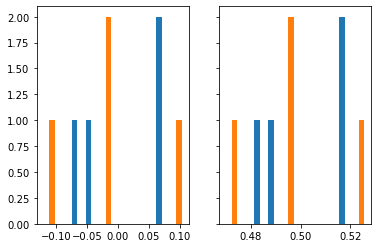

In [48]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns 

n_hist_bins = 100

fig, axs = plt.subplots(1,2, sharey=True)

# sns.histplot(cue.detach().numpy(), stat='percent',  log_scale=(False, True),
#              bins=n_hist_bins, #binrange=(layer_outputs.min(), layer_outputs.max()),
#              ax=axs[0], color='plum', edgecolor='0.1')


# sns.histplot(output.detach().numpy().flatten(), stat='percent',  log_scale=(False, True),
#              bins=n_hist_bins, #binrange=(layer_outputs.min(), layer_outputs.max()),
#              ax=axs[1], color='teal', edgecolor='0.1')

axs[0].hist(cue.detach().numpy()[0].reshape(2,-1).T)
axs[1].hist(output.detach().numpy()[0].reshape(2,-1).T)
